# Human Spinal Cord Single Sample

- **Creator**: Jiamao Liu (<liujiamao@stu.xmu.edu.cn>)
- **Date of Creation:** 20.05.2025
- **Date of Last Modification:** 20.05.2025 (Jiamao Liu; <liujiamao@stu.xmu.edu.cn>)

- In order to run this notebook, a trained model needs to be stored under ```/artifacts/{dataset}/models/{model_label}/{load_timestamp}```.
    - dataset: ```stereo_seq_spinal_cord_gw7```
    - model_label: ```single_sample```
    - load_timestamp: ```20052025_034359```
- Run this notebook in the nichecompass-reproducibility environment, installable from ```('/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/envs/environment.yaml')```.

## 1. Setup

### 1.1 Import Libraries

In [ ]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:32'
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Or specify the device directly

In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/utils")
import argparse
import gc
import os
import random
import shutil
import warnings
import logging
from datetime import datetime

import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
import mlflow
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scipy.stats as stats
import seaborn as sns
import squidpy as sq
import torch
from matplotlib import gridspec
from matplotlib.pyplot import rc_context
from pywaffle import Waffle
from sklearn.preprocessing import MinMaxScaler

from nichecompass.models import NicheCompass
from nichecompass.utils import (add_gps_from_gp_dict_to_adata,
                                compute_communication_gp_network,
                                visualize_communication_gp_network,
                                create_new_color_dict,
                                extract_gp_dict_from_mebocost_ms_interactions,
                                extract_gp_dict_from_nichenet_lrt_interactions,
                                extract_gp_dict_from_omnipath_lr_interactions,
                                filter_and_combine_gp_dict_gps_v2,
                                generate_enriched_gp_info_plots,
                                aggregate_obsp_matrix_per_cell_type,
                                create_cell_type_chord_plot_from_df
                                )

from analysis_utils import (add_cell_type_latent_cluster_emphasis,
                            add_sub_cell_type,
                            compute_cell_type_latent_clusters,
                            generate_gp_info_plots,
                            plot_category_in_latent_and_physical_space,
                            plot_cell_type_latent_clusters,
                            plot_latent,
                            plot_physical_latent_for_cell_types,
                            sankey,
                            store_top_gps_summary)

plt.rcParams["pdf.fonttype"] = 42  # 42 = TrueType, 3 = Type3（不可编辑）
plt.rcParams["font.family"] = "sans-serif" 
device = torch.device("cuda:0")

/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/cluster2/huanglab/jiamao/conda/envs/niche/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.2 Define Parameters

In [3]:
### Dataset ###
dataset = "stereo_seq_spinal_cord_gw7"
species = "human"
batches = ["gw7-1", "gw7-2", "gw7-3"]
spatial_key = "spatial"
n_neighbors = 4

### Model ###
# AnnData keys
counts_key = "counts"
adj_key = "spatial_connectivities"
cat_covariates_keys = ["batch"]
gp_names_key = "nichecompass_gp_names"
active_gp_names_key = "nichecompass_active_gp_names"
gp_targets_mask_key = "nichecompass_gp_targets"
gp_targets_categories_mask_key = "nichecompass_gp_targets_categories"
gp_sources_mask_key = "nichecompass_gp_sources"
gp_sources_categories_mask_key = "nichecompass_gp_sources_categories"
latent_key = "nichecompass_latent"

# Architecture
cat_covariates_embeds_injection = ["gene_expr_decoder"]
cat_covariates_embeds_nums = [3]
cat_covariates_no_edges = [True]
conv_layer_encoder = "gcnconv" # change to "gatv2conv" if enough compute and memory
active_gp_thresh_ratio = 0.01

# Trainer
n_epochs = 400
n_epochs_all_gps = 25
lr = 0.001
lambda_edge_recon = 500000.
lambda_gene_expr_recon = 300.
lambda_l1_masked = 0. # prior GP  regularization
lambda_l1_addon = 30. # de novo GP regularization
edge_batch_size = 1024 # increase if more memory available or decrease to save memory
n_sampled_neighbors = 4
use_cuda_if_available = True

### Analysis ###
cell_type_key = "broad_cell_type"
latent_leiden_resolution = 0.3
latent_cluster_key = f"latent_leiden_{str(latent_leiden_resolution)}"
sample_key = "batch"
spot_size = 30
differential_gp_test_results_key = "nichecompass_differential_gp_test_results"

### 1.3 Run Notebook Setup

In [4]:
# Ignore future warnings and user warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [5]:
# Get time of notebook execution for timestamping saved artifacts
now = datetime.now()
current_timestamp = now.strftime("%d%m%Y_%H%M%S")
current_timestamp

'21052025_022408'

In [5]:
current_timestamp = "20052025_034359"

### 1.4 Configure Paths and Create Directories

In [6]:
# Define paths
ga_data_folder_path = "/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/datasets/ga_data"
gp_data_folder_path = "/cluster2/huanglab/jiamao/Project/Tools/nichecompass-reproducibility/datasets/gp_data"
so_data_folder_path = "/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/SelectCells/H5AD"
omnipath_lr_network_file_path = f"{gp_data_folder_path}/omnipath_lr_network.csv"
collectri_tf_network_file_path = f"{gp_data_folder_path}/collectri_tf_network_{species}.csv"
nichenet_lr_network_file_path = f"{gp_data_folder_path}/nichenet_lr_network_v2_{species}.csv"
nichenet_ligand_target_matrix_file_path = f"{gp_data_folder_path}/nichenet_ligand_target_matrix_v2_{species}.csv"
mebocost_enzyme_sensor_interactions_folder_path = f"{gp_data_folder_path}/metabolite_enzyme_sensor_gps"
gene_orthologs_mapping_file_path = f"{ga_data_folder_path}/human_mouse_gene_orthologs.csv"

figure_folder_path = f"/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/nichecompass/artifacts/{dataset}/figures/single_sample/{current_timestamp}"
model_folder_path = f"/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/nichecompass/artifacts/{dataset}/models/single_sample/{current_timestamp}"
result_folder_path = f"/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/nichecompass/artifacts/{dataset}/results/single_sample/{current_timestamp}"

# Create required directories
os.makedirs(so_data_folder_path, exist_ok=True)
os.makedirs(model_folder_path, exist_ok=True)
os.makedirs(figure_folder_path, exist_ok=True)
os.makedirs(result_folder_path, exist_ok=True)

## 2. Prepare Model Training

### 2.1 Create Prior Knowledge Gene Program (GP) Mask
- NicheCompass expects a prior GP mask as input, which it will use to make its latent feature space interpretable (through linear masked decoders). 
- The user can provide a custom GP mask to NicheCompass based on the biological question of interest.
- As a default, here we create a GP mask based on three databases of prior knowledge of inter- and intracellular interaction pathways:
    - OmniPath (Ligand-Receptor GPs)
    - MEBOCOST (Enzyme-Sensor GPs)
    - NicheNet (Combined Interaction GPs)

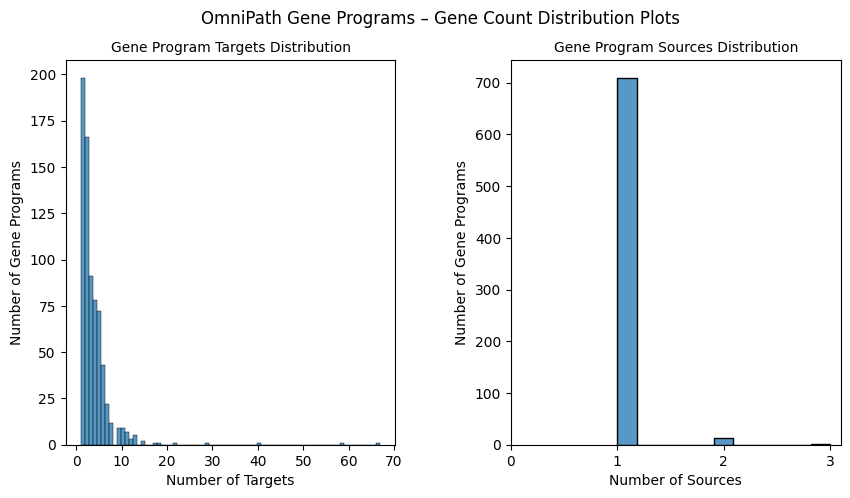

In [7]:
# Retrieve OmniPath GPs (source: ligand genes; target: receptor genes)
omnipath_gp_dict = extract_gp_dict_from_omnipath_lr_interactions(
    species=species,
    load_from_disk=False,
    save_to_disk=True,
    lr_network_file_path=omnipath_lr_network_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True,
    gp_gene_count_distributions_save_path=f"{figure_folder_path}" \
                                           "/omnipath_gp_gene_count_distributions.pdf")

In [8]:
# Display example OmniPath GP
omnipath_gp_names = list(omnipath_gp_dict.keys())
random.shuffle(omnipath_gp_names)
omnipath_gp_name = omnipath_gp_names[0]
print(f"{omnipath_gp_name}: {omnipath_gp_dict[omnipath_gp_name]}")

TNFRSF1B_ligand_receptor_GP: {'sources': ['TNFRSF1B'], 'targets': ['BIRC2', 'MAP3K1', 'TNF'], 'sources_categories': ['ligand'], 'targets_categories': ['receptor', 'receptor', 'receptor']}


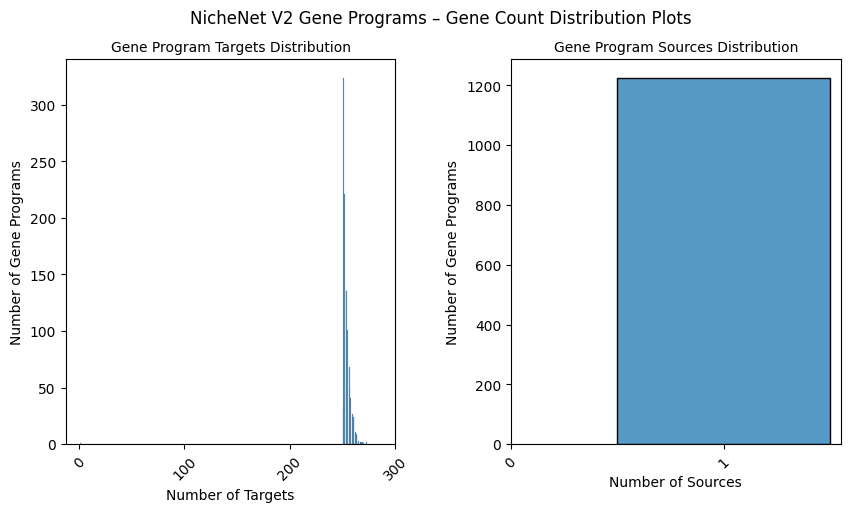

In [10]:
# Retrieve NicheNet GPs (source: ligand genes; target: receptor genes, target genes)
nichenet_gp_dict = extract_gp_dict_from_nichenet_lrt_interactions(
    species=species,
    version="v2",
    keep_target_genes_ratio=1.,
    max_n_target_genes_per_gp=250,
    load_from_disk=True,
    save_to_disk=True,
    lr_network_file_path=nichenet_lr_network_file_path,
    ligand_target_matrix_file_path=nichenet_ligand_target_matrix_file_path,
    gene_orthologs_mapping_file_path=gene_orthologs_mapping_file_path,
    plot_gp_gene_count_distributions=True)

In [12]:
# Display example NicheNet GP
nichenet_gp_names = list(nichenet_gp_dict.keys())
random.shuffle(nichenet_gp_names)
nichenet_gp_name = nichenet_gp_names[0]
print(f"{nichenet_gp_name}: {nichenet_gp_dict[nichenet_gp_name]}")

NOG_ligand_receptor_target_gene_GP: {'sources': ['NOG'], 'targets': ['BMPR1A', 'BMPR2', 'BMPR1B', 'ABCA1', 'ABCG2', 'ADK', 'ADM', 'AFF3', 'AHR', 'AJUBA', 'AKAP1', 'AKR1C3', 'ANKRD1', 'ANKRD28', 'ANXA1', 'AR', 'AREG', 'ARHGEF3', 'ASS1', 'ATAD2', 'ATF3', 'ATP1B1', 'AURKA', 'B4GALT1', 'BAMBI', 'BAX', 'BCL2', 'BCL2L1', 'BCL2L11', 'BCL6', 'BDNF', 'BHLHE40', 'BIRC3', 'BIRC5', 'BMP4', 'BNC2', 'CA12', 'CALD1', 'CAMK2D', 'CAV1', 'CCL2', 'CCL20', 'CCNA2', 'CCNB2', 'CCND1', 'CCND2', 'CCNE2', 'CCNG2', 'CD109', 'CD44', 'CDH1', 'CDH2', 'CDK6', 'CDKN1A', 'CDKN2B', 'CEBPB', 'CENPF', 'CHD2', 'CITED2', 'CLDN1', 'CPEB4', 'CTNNB1', 'CXADR', 'CXCR4', 'CYB5A', 'CYFIP2', 'CYP1A1', 'CYP1B1', 'DDAH1', 'DDIT3', 'DDIT4', 'DHRS3', 'DKK1', 'DKK3', 'DPP4', 'DTL', 'DUSP1', 'DUSP6', 'ECT2', 'EDN1', 'EFEMP1', 'EFNA1', 'EGFR', 'EGR1', 'ELL2', 'ELMO1', 'EMP1', 'ENC1', 'ENPP2', 'EPHA2', 'EPHA4', 'ERBB3', 'ETS1', 'ETV1', 'FAS', 'FASN', 'FGF2', 'FGF8', 'FKBP5', 'FN1', 'FOS', 'FOXP1', 'FST', 'GADD45A', 'GADD45B', 'GATA4', '

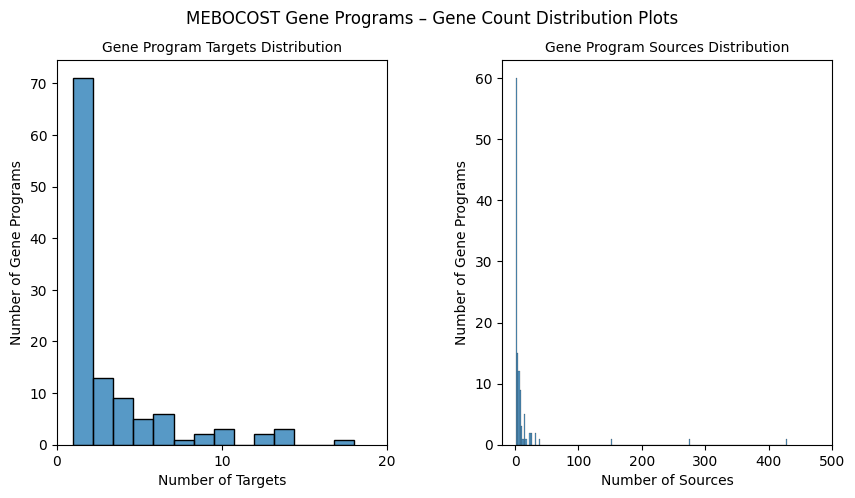

In [13]:
# Retrieve MEBOCOST GPs (source: enzyme genes; target: sensor genes)
mebocost_gp_dict = extract_gp_dict_from_mebocost_ms_interactions(
    dir_path=mebocost_enzyme_sensor_interactions_folder_path,
    species=species,
    plot_gp_gene_count_distributions=True)

In [14]:
# Display example MEBOCOST GP
mebocost_gp_names = list(mebocost_gp_dict.keys())
random.shuffle(mebocost_gp_names)
mebocost_gp_name = mebocost_gp_names[0]
print(f"{mebocost_gp_name}: {mebocost_gp_dict[mebocost_gp_name]}")

Estrone_metabolite_enzyme_sensor_GP: {'sources': ['HSD17B1', 'HSD17B11', 'HSD17B12', 'HSD17B2', 'HSD17B6', 'HSD17B7', 'HSD17B8'], 'sources_categories': ['enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme', 'enzyme'], 'targets': ['ESR1'], 'targets_categories': ['sensor']}


In [15]:
# Filter and combine GPs
gp_dicts = [omnipath_gp_dict, nichenet_gp_dict, mebocost_gp_dict]
combined_gp_dict = filter_and_combine_gp_dict_gps_v2(
    gp_dicts,
    verbose=True)

Combining ACE2_ligand_receptor_GP and ACE2_ligand_receptor_target_gene_GP.
Combining ADCYAP1_ligand_receptor_GP and ADCYAP1_ligand_receptor_target_gene_GP.
Combining ADGRE5_ligand_receptor_GP and ADGRE5_ligand_receptor_target_gene_GP.
Combining ADIPOQ_ligand_receptor_GP and ADIPOQ_ligand_receptor_target_gene_GP.
Combining ADM_ligand_receptor_GP and ADM_ligand_receptor_target_gene_GP.
Combining ADM2_ligand_receptor_GP and ADM2_ligand_receptor_target_gene_GP.
Combining AGRP_ligand_receptor_GP and AGRP_ligand_receptor_target_gene_GP.
Combining AGT_ligand_receptor_GP and AGT_ligand_receptor_target_gene_GP.
Combining ALCAM_ligand_receptor_GP and ALCAM_ligand_receptor_target_gene_GP.
Combining ALKAL1_ligand_receptor_GP and ALKAL1_ligand_receptor_target_gene_GP.
Combining ALKAL2_ligand_receptor_GP and ALKAL2_ligand_receptor_target_gene_GP.
Combining AMBN_ligand_receptor_GP and AMBN_ligand_receptor_target_gene_GP.
Combining AMELX_ligand_receptor_GP and AMELX_ligand_receptor_target_gene_GP.
Com

### 2.2 Load Data & Compute Spatial Neighbor Graph

- NicheCompass expects a precomputed spatial adjacency matrix stored in 'adata.obsp[adj_key]'.
- The user can customize the spatial neighbor graph construction based on the biological question of interest.
- In the sample integration setting, we will compute a separate spatial adjacency matrix for each sample and combine them as disconnected components.

In [15]:
so_data_folder_path

'/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/SelectCells/H5AD'

In [16]:
adata_batch_list = []

for batch in batches:
    print(f"Processing batch {batch}...")
    print("Loading data...")
    adata_batch = sc.read_h5ad(
        f"{so_data_folder_path}/SeuratObj_{batch}.h5ad")
    adata_batch.obs[sample_key] = batch
    adata_batch.layers['counts'] = adata_batch.X.copy()
    adata_batch.obsm['spatial'] = adata_batch.obsm['X_cod']

    print("Computing spatial neighborhood graph...\n")
    # Compute (separate) spatial neighborhood graphs
    sq.gr.spatial_neighbors(adata_batch,
                            coord_type="generic",
                            spatial_key=spatial_key,
                            n_neighs=n_neighbors)
    
    # Make adjacency matrix symmetric
    adata_batch.obsp[adj_key] = (
        adata_batch.obsp[adj_key].maximum(
            adata_batch.obsp[adj_key].T))
    adata_batch_list.append(adata_batch)
adata = ad.concat(adata_batch_list, join="inner")


Processing batch gw7-1...
Loading data...
Computing spatial neighborhood graph...

Processing batch gw7-2...
Loading data...
Computing spatial neighborhood graph...

Processing batch gw7-3...
Loading data...
Computing spatial neighborhood graph...



In [17]:

# Combine spatial neighborhood graphs as disconnected components
batch_connectivities = []
len_before_batch = 0
for i in range(len(adata_batch_list)):
    if i == 0: # first batch
        after_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[0].shape[0],
            (adata.shape[0] -
            adata_batch_list[0].shape[0])))
        batch_connectivities.append(sp.hstack(
            (adata_batch_list[0].obsp[adj_key],
            after_batch_connectivities_extension)))
    elif i == (len(adata_batch_list) - 1): # last batch
        before_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[i].shape[0],
            (adata.shape[0] -
            adata_batch_list[i].shape[0])))
        batch_connectivities.append(sp.hstack(
            (before_batch_connectivities_extension,
            adata_batch_list[i].obsp[adj_key])))
    else: # middle batches
        before_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[i].shape[0], len_before_batch))
        after_batch_connectivities_extension = sp.csr_matrix(
            (adata_batch_list[i].shape[0],
            (adata.shape[0] -
            adata_batch_list[i].shape[0] -
            len_before_batch)))
        batch_connectivities.append(sp.hstack(
            (before_batch_connectivities_extension,
            adata_batch_list[i].obsp[adj_key],
            after_batch_connectivities_extension)))
    len_before_batch += adata_batch_list[i].shape[0]
adata.obsp[adj_key] = sp.vstack(batch_connectivities)

### 2.3 Add GP Mask to Data

In [18]:
# Add the GP dictionary as binary masks to the adata
add_gps_from_gp_dict_to_adata(
    gp_dict=combined_gp_dict,
    adata=adata,
    gp_targets_mask_key=gp_targets_mask_key,
    gp_targets_categories_mask_key=gp_targets_categories_mask_key,
    gp_sources_mask_key=gp_sources_mask_key,
    gp_sources_categories_mask_key=gp_sources_categories_mask_key,
    gp_names_key=gp_names_key,
    min_genes_per_gp=2,
    min_source_genes_per_gp=1,
    min_target_genes_per_gp=1,
    max_genes_per_gp=None,
    max_source_genes_per_gp=None,
    max_target_genes_per_gp=None)

### 2.4 Explore Data (annotation need!!!)

In [19]:
adata

AnnData object with n_obs × n_vars = 13584 × 30322
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'batch'
    uns: 'nichecompass_sources_categories_label_encoder', 'nichecompass_targets_categories_label_encoder', 'nichecompass_source_genes_idx', 'nichecompass_target_genes_idx', 'nichecompass_genes_idx', 'nichecompass_gp_names'
    obsm: 'X_cod', 'spatial'
    varm: 'nichecompass_gp_sources', 'nichecompass_gp_targets', 'nichecompass_gp_sources_categories', 'nichecompass_gp_targets_categories'
    layers: 'counts'
    obsp: 'spatial_connectivities'

## 3. Train Model

### 3.1 Initialize, Train & Save Model

In [19]:
# Initialize model
model = NicheCompass(adata,
                     counts_key=counts_key,
                     adj_key=adj_key,
                     cat_covariates_embeds_injection=cat_covariates_embeds_injection,
                     cat_covariates_keys=cat_covariates_keys,
                     cat_covariates_no_edges=cat_covariates_no_edges,
                     cat_covariates_embeds_nums=cat_covariates_embeds_nums,
                     gp_names_key=gp_names_key,
                     active_gp_names_key=active_gp_names_key,
                     gp_targets_mask_key=gp_targets_mask_key,
                     gp_targets_categories_mask_key=gp_targets_categories_mask_key,
                     gp_sources_mask_key=gp_sources_mask_key,
                     gp_sources_categories_mask_key=gp_sources_categories_mask_key,
                     latent_key=latent_key,
                     conv_layer_encoder=conv_layer_encoder,
                     active_gp_thresh_ratio=active_gp_thresh_ratio)

--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
CATEGORICAL COVARIATES EMBEDDINGS INJECTION -> ['gene_expr_decoder']
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 30322, n_cat_covariates_embed_input: 0, n_hidden: 1454, n_latent: 1354, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1354, n_addon_gp_input: 100, n_cat_covariates_embed_input: 3, n_output: 30322
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1354, n_addon_gp_input: 100, n_cat_covariates_embed_input: 3, n_output: 30322


In [20]:
# Train model
model.train(n_epochs=n_epochs,
            n_epochs_all_gps=n_epochs_all_gps,
            lr=lr,
            lambda_edge_recon=lambda_edge_recon,
            lambda_gene_expr_recon=lambda_gene_expr_recon,
            lambda_l1_masked=lambda_l1_masked,
            edge_batch_size=edge_batch_size,†
            n_sampled_neighbors=n_sampled_neighbors,
            use_cuda_if_available=use_cuda_if_available,
            verbose=False)


--- INITIALIZING TRAINER ---
Number of training nodes: 12226
Number of validation nodes: 1358
Number of training edges: 24785
Number of validation edges: 2753
Edge batch size: 1024
Node batch size: None

--- MODEL TRAINING ---


Epoch 1/400 |--------------------| 0.2% train_global_loss: 6986381.4200; train_optim_loss: 6986381.4200; val_global_loss: 5412449.1667; val_optim_loss: 5412449.1667
Epoch 2/400 |--------------------| 0.5% train_global_loss: 4249884.2300; train_optim_loss: 4249884.2300; val_global_loss: 3198415.2500; val_optim_loss: 3198415.2500
Epoch 3/400 |--------------------| 0.8% train_global_loss: 2450472.6700; train_optim_loss: 2450472.6700; val_global_loss: 1840375.0833; val_optim_loss: 1840375.0833
Epoch 4/400 |--------------------| 1.0% train_global_loss: 1513286.4600; train_optim_loss: 1513286.4600; val_global_loss: 1345910.5833; val_optim_loss: 1345910.5833
Epoch 5/400 |--------------------| 1.2% train_global_loss: 1288618.9900; train_optim_loss: 1288618.9900; val_global_loss: 1265885.4583; val_optim_loss: 1265885.4583
Epoch 6/400 |--------------------| 1.5% train_global_loss: 1235814.0550; train_optim_loss: 1235814.0550; val_global_loss: 1236271.5000; val_optim_loss: 1236271.5000
Epoch 7/40

In [21]:
# Compute latent neighbor graph
sc.pp.neighbors(model.adata,
                use_rep=latent_key,
                key_added=latent_key)

# Compute UMAP embedding
sc.tl.umap(model.adata,
           neighbors_key=latent_key)

In [22]:
# Save trained model
model.save(dir_path=model_folder_path,
           overwrite=True,
           save_adata=True,
           adata_file_name="adata.h5ad")

## 4. Analysis

In [5]:
load_timestamp = current_timestamp
# load_timestamp = current_timestamp # uncomment if you trained the model in this notebook

figure_folder_path = f"../../artifacts/{dataset}/figures/single_sample/{load_timestamp}"
model_folder_path = f"../../artifacts/{dataset}/models/single_sample/{load_timestamp}"
result_folder_path = f"../../artifacts/{dataset}/results/single_sample/{load_timestamp}"

os.makedirs(figure_folder_path, exist_ok=True)

In [7]:
# Load trained model
model = NicheCompass.load(dir_path=model_folder_path,
                          adata=None,
                          adata_file_name="adata.h5ad",
                          gp_names_key=gp_names_key)

--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
CATEGORICAL COVARIATES EMBEDDINGS INJECTION -> ['gene_expr_decoder']
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 30322, n_cat_covariates_embed_input: 0, n_hidden: 1454, n_latent: 1354, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1354, n_addon_gp_input: 100, n_cat_covariates_embed_input: 3, n_output: 30322
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1354, n_addon_gp_input: 100, n_cat_covariates_embed_input: 3, n_output: 30322


### 4.1 Visualize NicheCompass Latent GP Space

Let's look at the preservation of cell type annotations in the latent GP space. Note that the goal of NicheCompass is not a separation of cell types but rather to identify spatially consistent cell niches.

In [25]:
cell_type_colors = {
    'Microglia': '#8FBC8F',       # 苔藓绿 - 小胶质细胞特有标记色
    'Neural_progenitor': '#FFD700', # 标准金黄 - 增殖细胞经典标识色
    'Excitatory': '#4682B4',      # 铁蓝 - 兴奋性神经元基准色
    'Inhibitory': '#CD5C5C',      # 赤陶红 - GABA能神经元标准对比色 
    'Motor_neuron': '#9370DB',    # 紫丁香色 - 运动系统统一配色
    'APC': '#2E8B57',             # 海洋绿 - 胶质前体细胞特征色
    'Trip': '#FF8C00',            # 琥珀橙 - 稀有细胞类型警示色
    'Ependymal': '#7AC5CD',       # 冰河蓝 - 室管膜细胞流体动力学关联色
    'Unknown': '#A9A99A',         # 玄武灰 - 未鉴定细胞标准中性色
    '-1': '#DCDCDC'               # 雾白 - 技术噪声/背景信号标识
}

In [ ]:
# Create plot of cell type annotations in physical and latent space
groups = None
save_fig = True
file_path = f"{figure_folder_path}/" \
            "cell_types_latent_physical_space.pdf"

fig = plt.figure(figsize=(12, 14))
title = fig.suptitle(t=f"Cell Types " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=len(samples),
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=[cell_type_key],
           groups=groups,
           palette=cell_type_colors,
           title=f"Cell Types in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=[cell_type_key],
                  groups=groups,
                  palette=cell_type_colors,
                  spot_size=spot_size,
                  title=f"Cell Types in Physical Space \n"
                        f"(Sample: {sample})",
                  legend_loc=None,
                  ax=axs[idx+1],
                  show=False)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight")
plt.show()

### 4.2 Identify Niches

We compute Leiden clustering of the NicheCompass latent GP space to identify spatially consistent cell niches.

In [23]:
model.adata

AnnData object with n_obs × n_vars = 13584 × 30322
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'batch'
    uns: 'nichecompass_sources_categories_label_encoder', 'nichecompass_targets_categories_label_encoder', 'nichecompass_source_genes_idx', 'nichecompass_target_genes_idx', 'nichecompass_genes_idx', 'nichecompass_gp_names', 'nichecompass_active_gp_names', 'nichecompass_latent', 'umap'
    obsm: 'X_cod', 'spatial', 'nichecompass_latent', 'X_umap'
    varm: 'nichecompass_gp_sources', 'nichecompass_gp_targets', 'nichecompass_gp_sources_categories', 'nichecompass_gp_targets_categories'
    layers: 'counts'
    obsp: 'spatial_connectivities', 'nichecompass_latent_distances', 'nichecompass_latent_connectivities'

In [9]:
latent_leiden_resolution = 0.2
# Compute latent Leiden clustering
sc.tl.leiden(adata=model.adata,
             resolution=latent_leiden_resolution,
             key_added=latent_cluster_key,
             neighbors_key=latent_key)
latent_cluster_colors = create_new_color_dict(
    adata=model.adata,
    cat_key=latent_cluster_key)

samples = model.adata.obs[sample_key].unique()

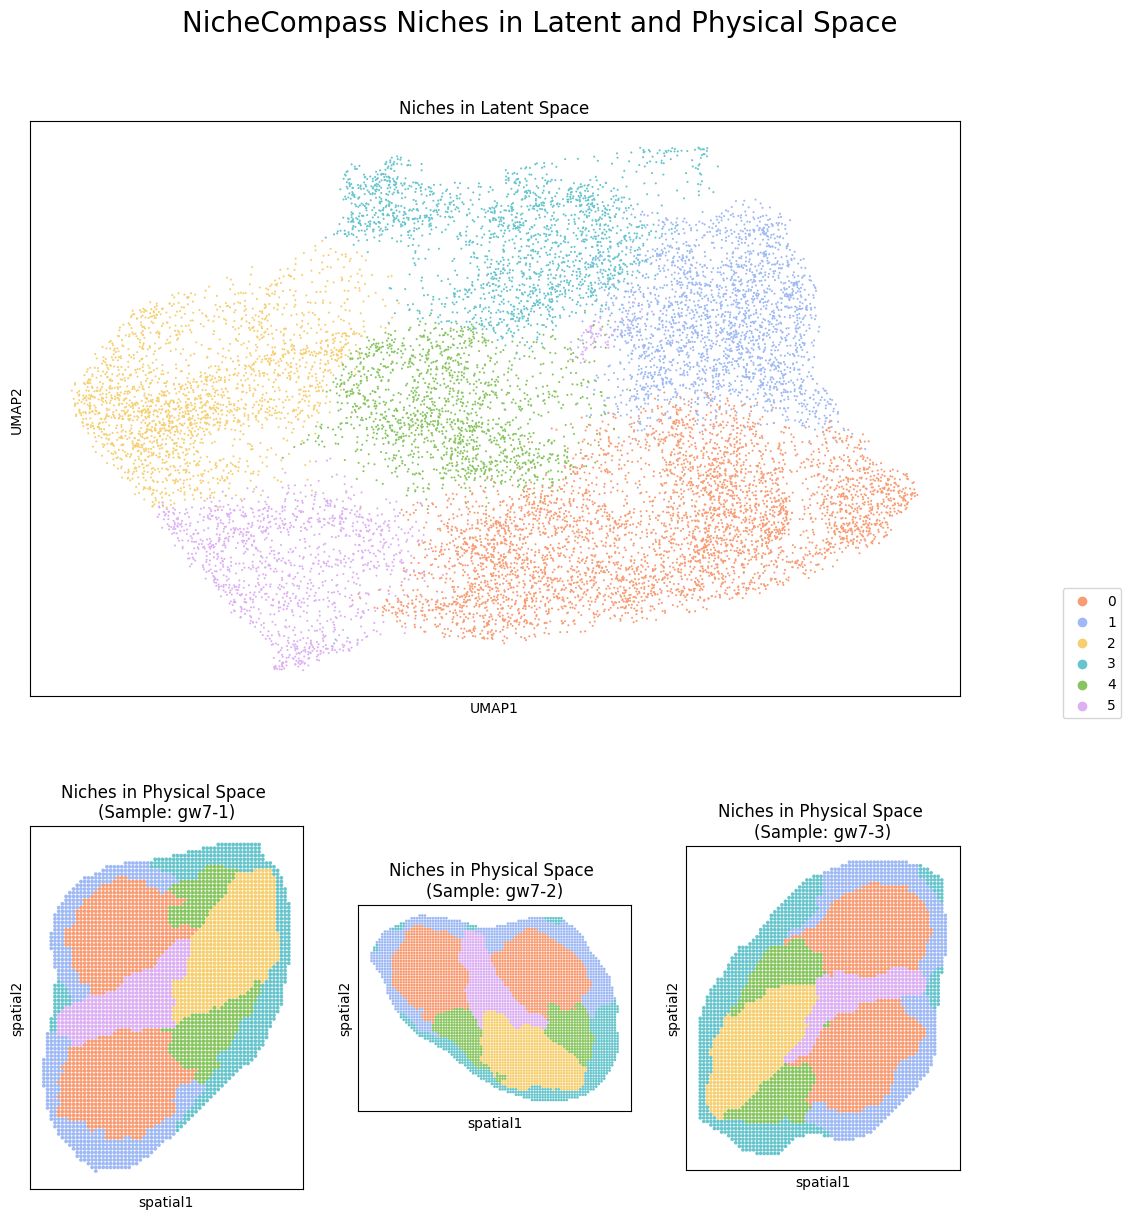

In [10]:
# Create plot of latent cluster / niche annotations in physical and latent space
groups = None # set this to a specific cluster for easy visualization, e.g. ["17"]
save_fig = True
file_path = f"{figure_folder_path}/" \
            f"res_{latent_leiden_resolution}_" \
            "niches_latent_physical_space.pdf"

fig = plt.figure(figsize=(12, 14))
title = fig.suptitle(t=f"NicheCompass Niches " \
                       "in Latent and Physical Space",
                     y=0.96,
                     x=0.55,
                     fontsize=20)
spec1 = gridspec.GridSpec(ncols=1,
                          nrows=2,
                          width_ratios=[1],
                          height_ratios=[3, 2])
spec2 = gridspec.GridSpec(ncols=len(samples),
                          nrows=2,
                          width_ratios=[1] * len(samples),
                          height_ratios=[3, 2])
axs = []
axs.append(fig.add_subplot(spec1[0]))
sc.pl.umap(adata=model.adata,
           color=[latent_cluster_key],
           groups=groups,
           palette=latent_cluster_colors,
           title=f"Niches in Latent Space",
           ax=axs[0],
           show=False)
for idx, sample in enumerate(samples):
    axs.append(fig.add_subplot(spec2[len(samples) + idx]))
    sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=[latent_cluster_key],
                  groups=groups,
                  palette=latent_cluster_colors,
                  spot_size=spot_size,
                  title=f"Niches in Physical Space \n"
                        f"(Sample: {sample})",
                  legend_loc=None,
                  ax=axs[idx+1],
                  show=False)

# Create and position shared legend
handles, labels = axs[0].get_legend_handles_labels()
lgd = fig.legend(handles,
                 labels,
                 loc="center left",
                 bbox_to_anchor=(0.98, 0.5))
axs[0].get_legend().remove()

# Adjust, save and display plot
plt.subplots_adjust(wspace=0.2, hspace=0.25)
if save_fig:
    fig.savefig(file_path,
                bbox_extra_artists=(lgd, title),
                bbox_inches="tight",
                format="pdf")  # 关键参数
plt.show()

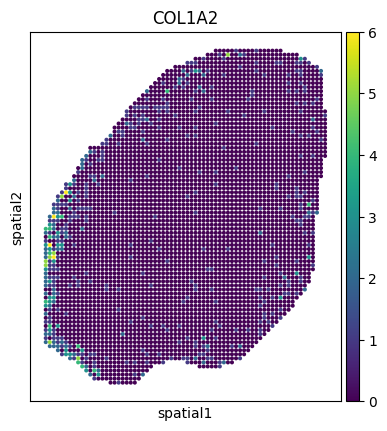

In [26]:
sc.pl.spatial(adata=model.adata[model.adata.obs[sample_key] == sample],
                  color=['COL1A2'],
                  spot_size=30,
            )

### 4.2x subset model.adata by niche

In [11]:
model.adata

AnnData object with n_obs × n_vars = 13584 × 30322
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'cell', 'x', 'y', 'batch', 'latent_leiden_0.3'
    uns: 'nichecompass_active_gp_names', 'nichecompass_genes_idx', 'nichecompass_gp_names', 'nichecompass_latent', 'nichecompass_source_genes_idx', 'nichecompass_sources_categories_label_encoder', 'nichecompass_target_genes_idx', 'nichecompass_targets_categories_label_encoder', 'umap', 'leiden', 'latent_leiden_0.3_colors'
    obsm: 'X_cod', 'X_umap', 'nichecompass_latent', 'spatial'
    varm: 'nichecompass_gp_sources', 'nichecompass_gp_sources_categories', 'nichecompass_gp_targets', 'nichecompass_gp_targets_categories'
    layers: 'counts'
    obsp: 'nichecompass_latent_connectivities', 'nichecompass_latent_distances', 'spatial_connectivities'

In [12]:
latent_cluster_key

'latent_leiden_0.3'

In [14]:
model.adata.obs.head()

,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,cell,x,y,batch,latent_leiden_0.3
GW6:9330_14550,256.0,208,256.0,208,GW6:9330_14550,9330.0,14550.0,gw7-1,3
GW6:11010_13860,586.0,428,586.0,428,GW6:11010_13860,11010.0,13860.0,gw7-1,2
GW6:10200_15240,414.0,310,414.0,310,GW6:10200_15240,10200.0,15240.0,gw7-1,0
GW6:10620_13380,353.0,265,353.0,265,GW6:10620_13380,10620.0,13380.0,gw7-1,3
GW6:9810_14550,402.0,323,402.0,323,GW6:9810_14550,9810.0,14550.0,gw7-1,5


In [23]:
selected_indices = model.adata.obs['latent_leiden_0.3'].isin(['0', '2', '4', '5'])

# 获取对应的x,y坐标
selected_coords = model.adata.obs.loc[selected_indices, ['x', 'y']]

In [24]:
selected_coords.head()

,x,y
GW6:11010_13860,11010.0,13860.0
GW6:10200_15240,10200.0,15240.0
GW6:9810_14550,9810.0,14550.0
GW6:9900_15300,9900.0,15300.0
GW6:10770_14640,10770.0,14640.0


In [26]:
result_folder_path

'/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ST/data/CalculateCells/nichecompass/artifacts/stereo_seq_spinal_cord_gw7/results/single_sample/20052025_034359'

In [27]:
selected_coords.to_csv(f'{result_folder_path}/Barcode_selected_by_niche_gw7.csv')

The current document is only used for filtering, and it ends here.